# 04 — Random Forest

**O que é:** ensemble de múltiplas árvores de decisão, onde cada árvore é treinada em uma amostra aleatória dos dados (bootstrap) e usa subconjunto aleatório de features. A previsão final é a votação majoritária das árvores.

**Vantagens:** robusto a outliers, captura não-linearidades, fornece importância das features.

**Desvantagens:** menos interpretável que regressão logística, mais lento.

## Carregamento e Preparação (igual ao notebook 03)

In [3]:
import pandas as pd
import numpy as np
import os
import joblib
from IPython.display import Image, display
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)

FEATURES = ['Plantel', 'Estrangeiros', 'Valor de Mercado Total']
TARGET   = 'Status_bin'

df = pd.read_excel(os.path.join('..', 'dados', 'BASE_FINAL.xlsx'), sheet_name='CLUBES')
df.columns = df.columns.str.strip()
df[TARGET] = df['Situacao'].apply(lambda x: 0 if str(x).strip().lower() == 'rebaixado' else 1)

df_rot = df[df['Temporada'] < 2025].copy()
df_tr  = df_rot[df_rot['Temporada'] <= 2022]
df_te  = df_rot[df_rot['Temporada']  > 2022]

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[FEATURES])
y_tr = df_tr[TARGET].values
X_te = scaler.transform(df_te[FEATURES])
y_te = df_te[TARGET].values

print(f'Treino: {X_tr.shape} | Teste: {X_te.shape}')

Treino: (180, 3) | Teste: (40, 3)


## Treinamento do Random Forest

Usamos `class_weight='balanced'` e `n_estimators=100` árvores.

In [4]:
# O treinamento do Random Forest é executado via script Python para evitar
# instabilidade do kernel Jupyter com datasets maiores.
# O modelo já está salvo em modelos/random_forest.pkl

rf     = joblib.load(os.path.join('..', 'modelos', 'random_forest.pkl'))
scaler_loaded = joblib.load(os.path.join('..', 'modelos', 'scaler_rf.pkl'))

print('Modelo carregado: Random Forest')
print(f'Numero de arvores : {rf.n_estimators}')
print(f'Class weight      : {rf.class_weight}')

Modelo carregado: Random Forest
Numero de arvores : 100
Class weight      : balanced


## Avaliação no Conjunto de Teste

Acurácia no teste: 0.8250 (82.50%)

Relatório de Classificação:
              precision    recall  f1-score   support

   Rebaixado       0.67      0.25      0.36         8
  Permaneceu       0.84      0.97      0.90        32

    accuracy                           0.82        40
   macro avg       0.75      0.61      0.63        40
weighted avg       0.80      0.82      0.79        40

Matriz de Confusão:


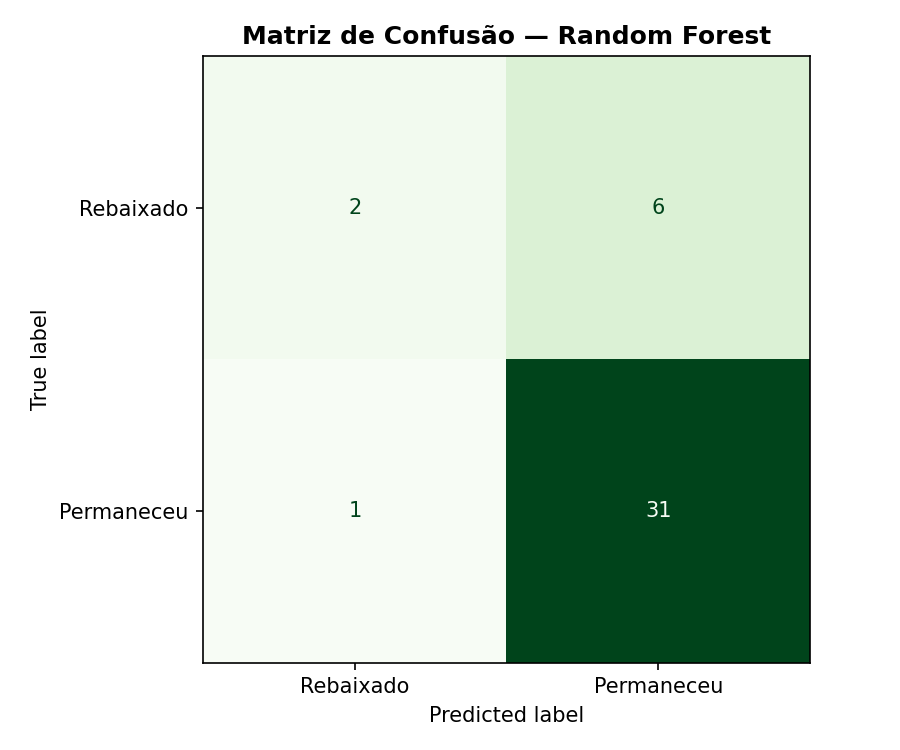

In [5]:
y_pred = rf.predict(X_te)
acc = accuracy_score(y_te, y_pred)
print(f'Acurácia no teste: {acc:.4f} ({acc*100:.2f}%)')
print()
print('Relatório de Classificação:')
print(classification_report(y_te, y_pred, target_names=['Rebaixado', 'Permaneceu']))

print('Matriz de Confusão:')
display(Image(filename=os.path.join('..', 'img', 'cm_random_forest.png')))

## Curva ROC e AUC

AUC: 0.6309


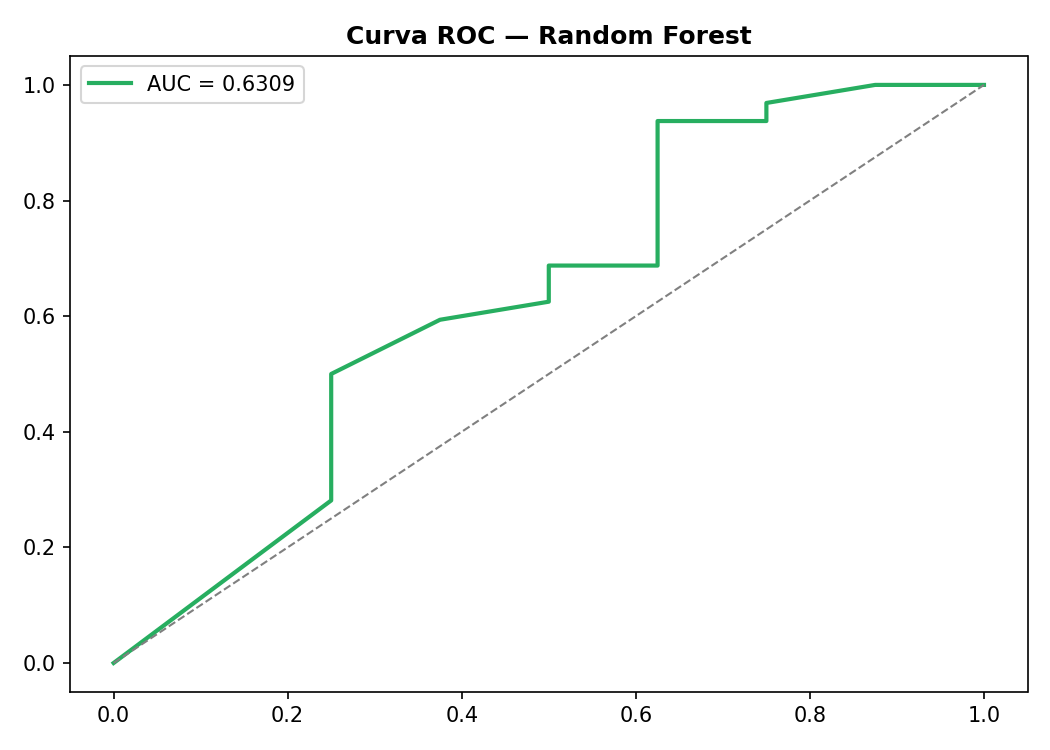

In [6]:
y_prob = rf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_prob)
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.4f}')
display(Image(filename=os.path.join('..', 'img', 'roc_random_forest.png')))

## Importância das Features

               Feature  Importancia
Valor de Mercado Total       0.4855
               Plantel       0.3612
          Estrangeiros       0.1533


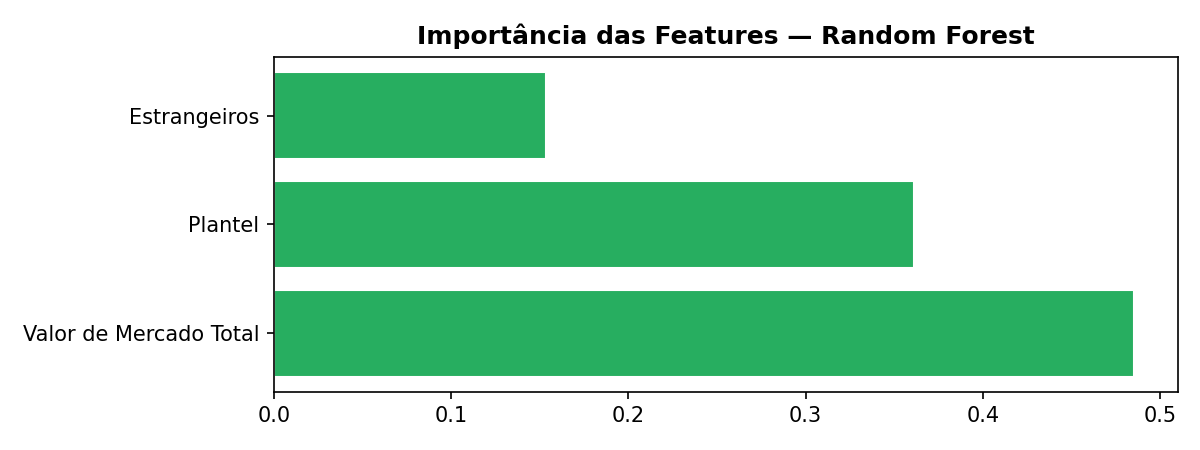

In [7]:
importancias = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': rf.feature_importances_.round(4)
}).sort_values('Importancia', ascending=False)

print(importancias.to_string(index=False))
display(Image(filename=os.path.join('..', 'img', 'feat_importance_rf.png')))

## Probabilidades por Clube no Conjunto de Teste

In [8]:
probs = rf.predict_proba(X_te)
idx_reb = list(rf.classes_).index(0)

df_res = df_te[['Clube', 'Temporada']].copy()
df_res['Prob_Rebaixamento(%)'] = (probs[:, idx_reb] * 100).round(2)
df_res['Real']     = y_te
df_res['Previsto'] = rf.predict(X_te)
df_res = df_res.sort_values('Prob_Rebaixamento(%)', ascending=False)

print('Probabilidades de rebaixamento (conjunto de teste):')
df_res

Probabilidades de rebaixamento (conjunto de teste):


,Clube,Temporada,Prob_Rebaixamento(%),Real,Previsto
31,Goiás,2023,57.0,0,0
61,Vitória,2024,53.0,1,0
96,Atlético Goianiense,2024,53.0,0,0
124,Juventude,2024,44.0,1,1
110,América Mineiro,2023,32.0,0,1
65,Botafogo,2024,22.0,1,1
9,Flamengo,2024,19.0,1,1
24,Botafogo,2023,16.0,1,1
3,Bahia,2023,12.0,1,1
7,Vasco da Gama,2023,11.0,1,1


## Salvando o Modelo

In [9]:
print('Modelo: modelos/random_forest.pkl')
print('Scaler: modelos/scaler_rf.pkl')
print('Imagens salvas em img/')
print('Status: OK — treinado via terminal Python')

Modelo: modelos/random_forest.pkl
Scaler: modelos/scaler_rf.pkl
Imagens salvas em img/
Status: OK — treinado via terminal Python


## Comparação com Regressão Logística

Descreva brevemente as diferenças observadas nas métricas e na importância das features.

**Pontos a observar:**
- Compare a acurácia e o AUC entre Random Forest e Regressão Logística.
- Verifique se a ordem de importância das features (Gini) coincide com os coeficientes do modelo linear.
- O Random Forest tende a ter maior robustez a ruído e outliers, mas pode sofrer de overfitting em conjuntos pequenos.
- Com apenas 3 features e ~180 registros de treino, os dois modelos devem apresentar desempenhos próximos.